# Linear Algebra

Importing Libraries

In [69]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

## 1. Vectors

A vector is a quantity that has both **magnitude and direction**. This characteristic distinguishes vectors from **scalars**, which only have magnitude.

* **Magnitude** refers to the **size or numerical value** of a quantity.
* **Direction** indicates the **orientation or the way in which the quantity acts**.

Graphically, vectors are usually represented by **arrows**. The **length of the arrow** indicates the **magnitude of the vector**, while the **arrowhead shows its direction**.


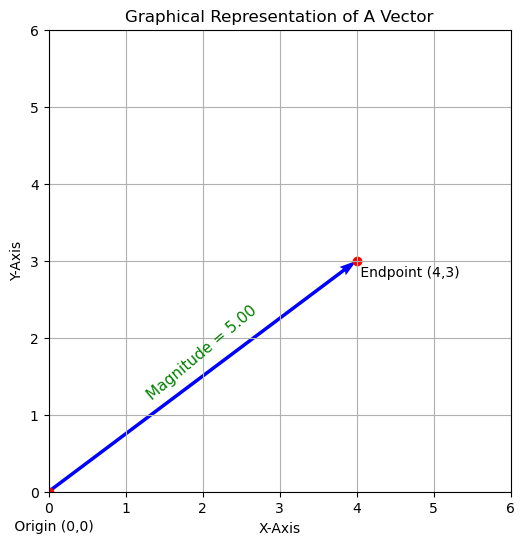

In [70]:
# Example Vector (4,3)
x, y = 4, 3   

# Magnitude
magnitude = np.sqrt(x**2 + y**2)

fig, ax = plt.subplots(figsize=(6,6))

# Draw Vector Arrow
ax.quiver(0, 0, x, y, angles='xy', scale_units='xy', scale=1, color='blue')

# Mark Origin And Endpoint
ax.scatter([0, x], [0, y], color='red')

# Annotate Origin
ax.text(-0.5, -0.5, ' Origin (0,0)', fontsize=10)

# Annotate Endpoint
ax.text(x, y - 0.2, f' Endpoint ({x},{y})', fontsize=10)

# Annotate Magnitude
ax.text(x/2, (y/2) - 0.3, f'Magnitude = {magnitude:.2f}', 
        fontsize=11, color='green', ha='center', rotation=40)


# Axis Formatting
ax.set_xlim(0, 6)
ax.set_ylim(0, 6)
ax.set_aspect('equal')
ax.set_xlabel('X-Axis')
ax.set_ylabel('Y-Axis')
ax.set_title('Graphical Representation of A Vector')

# Grid
ax.grid(True)

plt.show()

### 1.1 Vector Notation

There are different ways to represent vectors. Some of the most common methods are given below.

1. **Using a letter with an arrow above it:** A vector can be written as a letter with an arrow above it, such as $\vec{u}$, $\vec{v}$, or $\vec{a}$.

2. **Using bold letters:** Vectors can also be represented by bold letters, such as $\textbf{u}$, $\textbf{v}$, or $\textbf{a}$.

3. **Using directed line segment notation:** A vector can be represented as a directed line segment between two points. For example, if a vector starts at point $A$ and ends at point $B$, it is written as $\vec{AB}$.

4. **Using component notation (in coordinate geometry):** In coordinate geometry, vectors are often represented using component notation. A vector in two-dimensional space can be written as $\begin{bmatrix} x \ y \end{bmatrix}$, while a vector in three-dimensional space can be written as $\begin{bmatrix} x \ y \ z \end{bmatrix}$. These components show how much the vector moves along each coordinate axis.

### 1.2 Vector Operations

Vector Operations are mathematcial processes used to combine or manipulate vectors

Two of the main operations are:
- Vector Addition
- Scalar Multiplication

### Vector Addition

Vector addition is used to combine two or more vectors to obtain a **resultant vector**. When vectors are added, both their **magnitudes and directions** are taken into account.

**Algebraically**, vectors can be added by adding their corresponding components.

**Example:**

$$
\vec{u} = \begin{bmatrix}1 \\ 5\end{bmatrix},
\quad
\vec{v} = \begin{bmatrix}5 \\ 10\end{bmatrix}
$$

$$
\vec{u} + \vec{v} =
\begin{bmatrix}1 + 5 \\ 5 + 10\end{bmatrix}

\begin{bmatrix}6 \\ 15\end{bmatrix}
$$

**Graphically**, vector addition can be performed using the **triangle law of vector addition**.


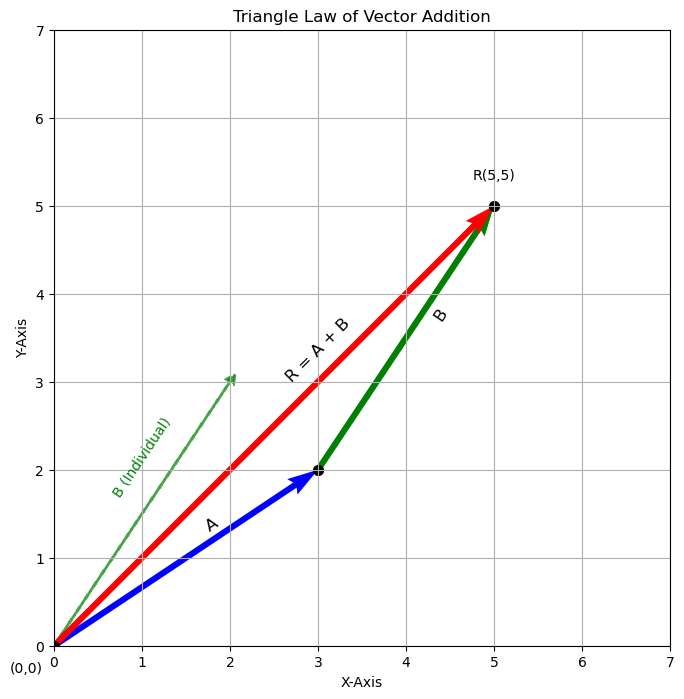

In [71]:
A = np.array([3, 2])
B = np.array([2, 3])
R = A + B

fig, ax = plt.subplots(figsize=(8, 8))
ax.set_title("Triangle Law of Vector Addition")
ax.set_xlabel('X-Axis')
ax.set_ylabel('Y-Axis')
ax.set_aspect('equal')
ax.grid()

def animate(i):
    ax.clear()
    ax.set_xlim(0, 7)
    ax.set_ylim(0, 7)
    ax.grid()
    ax.set_title("Triangle Law of Vector Addition")
    ax.set_xlabel('X-Axis')
    ax.set_ylabel('Y-Axis')
    ax.set_aspect('equal')
    
    artists = []
    
    if i >= 1:
        # Draw Vector A
        qA = ax.quiver(0, 0, A[0], A[1], angles='xy', scale_units='xy', scale=1, color='blue', width=0.01)
        angle_A = np.degrees(np.arctan2(A[1], A[0]))
        tA = ax.text(A[0]/2 + 0.3, A[1]/2 + 0.3, "A", fontsize=12, ha='center', rotation=angle_A)
        artists.extend([qA, tA])
    
    if i >= 2:
        # Draw Vector B Individually (From Origin) With Dashed Line
        arrB = ax.arrow(0, 0, B[0], B[1], head_width=0.1, head_length=0.1, fc='green', ec='green', linestyle='--', alpha=0.7, linewidth=2)
        angle_B = np.degrees(np.arctan2(B[1], B[0]))
        tB_ind = ax.text(B[0]/2, B[1]/2 + 0.2, "B (Individual)", fontsize=10, color='green', ha='center', rotation=angle_B)
        artists.extend([arrB, tB_ind])
    
    if i >= 3:
        # Draw Vector B Starting From A
        qB_tri = ax.quiver(A[0], A[1], B[0], B[1], angles='xy', scale_units='xy', scale=1, color='green', width=0.01)
        tB_tri = ax.text(A[0] + B[0]/2 + 0.4, A[1] + B[1]/2 + 0.2, "B", fontsize=12, ha='center', rotation=angle_B)
        artists.extend([qB_tri, tB_tri])
    
    if i >= 4:
        # Draw Resultant Vector R
        qR = ax.quiver(0, 0, R[0], R[1], angles='xy', scale_units='xy', scale=1, color='red', width=0.01)
        angle_R = np.degrees(np.arctan2(R[1], R[0]))
        tR = ax.text(R[0]/2 + 0.5, R[1]/2 + 0.5, "R = A + B", fontsize=12, ha='center', rotation=angle_R)
        artists.extend([qR, tR])
        
        # Mark Points
        scat = ax.scatter([0, A[0], A[0]+B[0]], [0, A[1], A[1]+B[1]], color='black', s=50)
        t0 = ax.text(0-0.5, 0-0.3, '(0,0)', fontsize=10)
        tR_pt = ax.text(A[0]+B[0], A[1]+B[1]+0.3, f'R({R[0]},{R[1]})', fontsize=10, ha='center')
        artists.extend([scat, t0, tR_pt])
    
    return artists

ani = FuncAnimation(fig, animate, frames=5, interval=1500, blit=True)

HTML(ani.to_jshtml())

Another graphical method of vector addition is the **parallelogram law**. In this method, the two vectors are drawn as adjacent sides of a parallelogram. The **diagonal of the parallelogram** then represents the **resultant vector**.

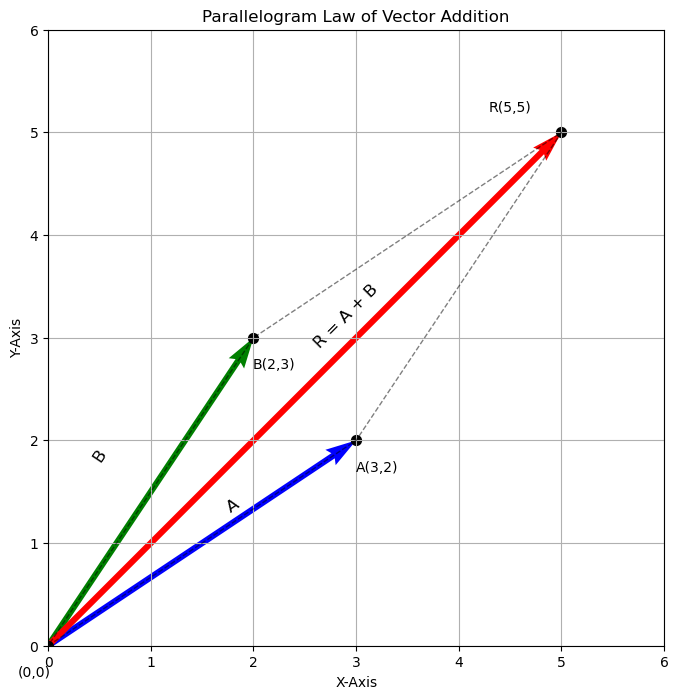

In [74]:
A = np.array([3, 2])
B = np.array([2, 3])
R = A + B

fig, ax = plt.subplots(figsize=(8, 8))
ax.set_title("Parallelogram Law of Vector Addition")
ax.set_xlabel('X-Axis')
ax.set_ylabel('Y-Axis')
ax.set_aspect('equal')
ax.grid()

def animate(i):
    ax.clear()
    ax.set_xlim(0, 6)
    ax.set_ylim(0, 6)
    ax.grid()
    ax.set_title("Parallelogram Law of Vector Addition")
    ax.set_xlabel('X-Axis')
    ax.set_ylabel('Y-Axis')
    ax.set_aspect('equal')
    
    artists = []
    
    if i >= 1:
        # Draw Vector A from origin
        angle_A = np.degrees(np.arctan2(A[1], A[0]))
        qA = ax.quiver(0, 0, A[0], A[1], angles='xy', scale_units='xy', scale=1, color='blue', width=0.01)
        tA = ax.text(A[0]/2 + 0.3, A[1]/2 + 0.3, "A", fontsize=12, ha='center', rotation=angle_A)
        artists.extend([qA, tA])
    
    if i >= 2:
        # Draw Vector B from origin
        angle_B = np.degrees(np.arctan2(B[1], B[0]))
        qB = ax.quiver(0, 0, B[0], B[1], angles='xy', scale_units='xy', scale=1, color='green', width=0.01)
        tB = ax.text(B[0]/2 - 0.5, B[1]/2 + 0.3, "B", fontsize=12, ha='center', rotation=angle_B)
        artists.extend([qB, tB])
    
    if i >= 3:
        # Draw Resultant Vector R (diagonal)
        angle_R = np.degrees(np.arctan2(R[1], R[0]))
        qR = ax.quiver(0, 0, R[0], R[1], angles='xy', scale_units='xy', scale=1, color='red', width=0.01)
        tR = ax.text(R[0]/2 + 0.4, R[1]/2 + 0.4, "R = A + B", fontsize=12, ha='center', rotation=angle_R)
        artists.extend([qR, tR])
    
    if i >= 4:
        # Draw parallelogram outline
        para = ax.plot([0, A[0], R[0], B[0], 0], [0, A[1], R[1], B[1], 0], 'k--', alpha=0.5, linewidth=1)[0]
        
        # Mark points
        scat = ax.scatter([0, A[0], B[0], R[0]], [0, A[1], B[1], R[1]], color='black', s=50)
        t0 = ax.text(0-0.3, 0-0.3, '(0,0)', fontsize=10)
        tA_pt = ax.text(A[0] + 0.2, A[1] - 0.3, f'A({A[0]},{A[1]})', fontsize=10, ha='center')
        tB_pt = ax.text(B[0] + 0.2, B[1] - 0.3, f'B({B[0]},{B[1]})', fontsize=10, ha='center')
        tR_pt = ax.text(R[0] - 0.5, R[1] + 0.2, f'R({R[0]},{R[1]})', fontsize=10, ha='center')
        artists.extend([para, scat, t0, tA_pt, tB_pt, tR_pt])
    
    return artists

ani = FuncAnimation(fig, animate, frames=5, interval=1500, blit=True)

HTML(ani.to_jshtml())